In [1]:
library(mlr)

Loading required package: ParamHelpers



In [2]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
data(diabetes, package = 'mclust')

In [4]:
?diabetes

No documentation for ‘diabetes’ in specified packages and libraries:
you could try ‘??diabetes’

In [5]:
diabetesTib <- as_tibble(diabetes)

In [6]:
summary(diabetesTib)

      class       glucose       insulin            sspg      
 Chemical:36   Min.   : 70   Min.   :  45.0   Min.   : 10.0  
 Normal  :76   1st Qu.: 90   1st Qu.: 352.0   1st Qu.:118.0  
 Overt   :33   Median : 97   Median : 403.0   Median :156.0  
               Mean   :122   Mean   : 540.8   Mean   :186.1  
               3rd Qu.:112   3rd Qu.: 558.0   3rd Qu.:221.0  
               Max.   :353   Max.   :1568.0   Max.   :748.0  

In [7]:
?diabetesTib

No documentation for ‘diabetesTib’ in specified packages and libraries:
you could try ‘??diabetesTib’

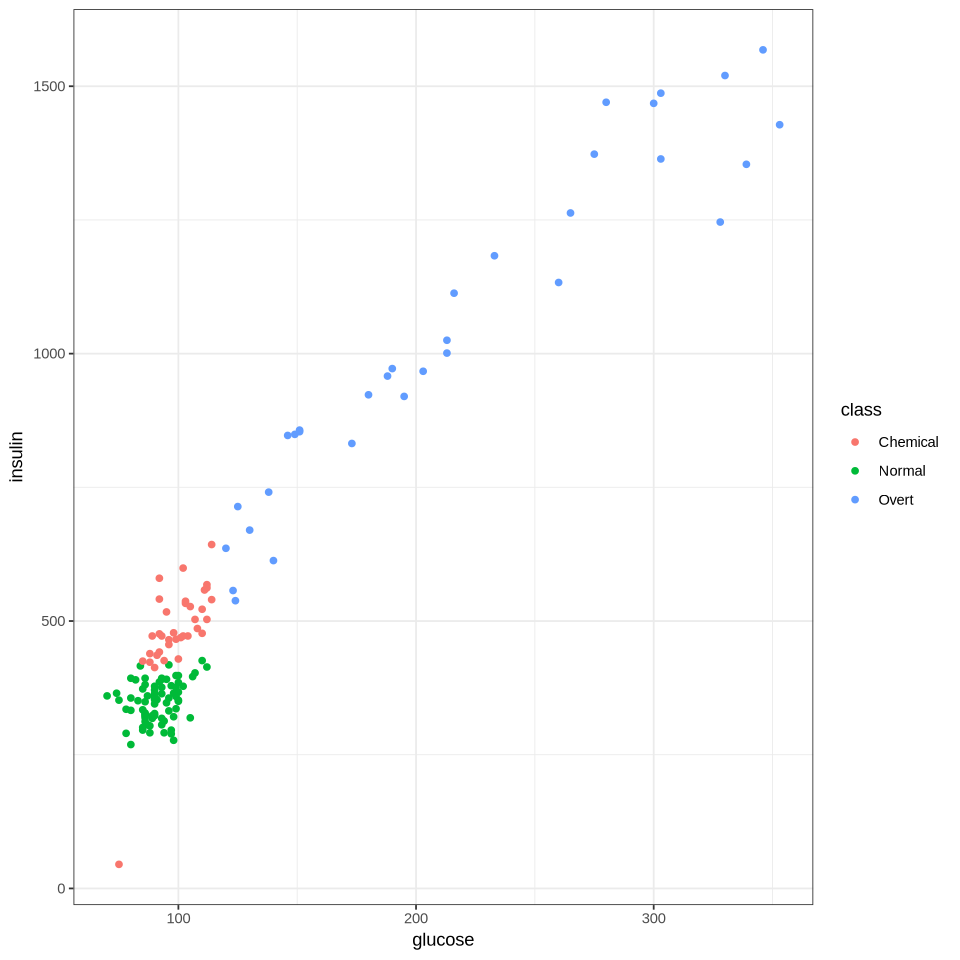

In [8]:
options(repr.plot.width = 8, repr.plot.height = 8)
ggplot(diabetesTib, aes(glucose, insulin, col=class)) + geom_point() + theme_bw()

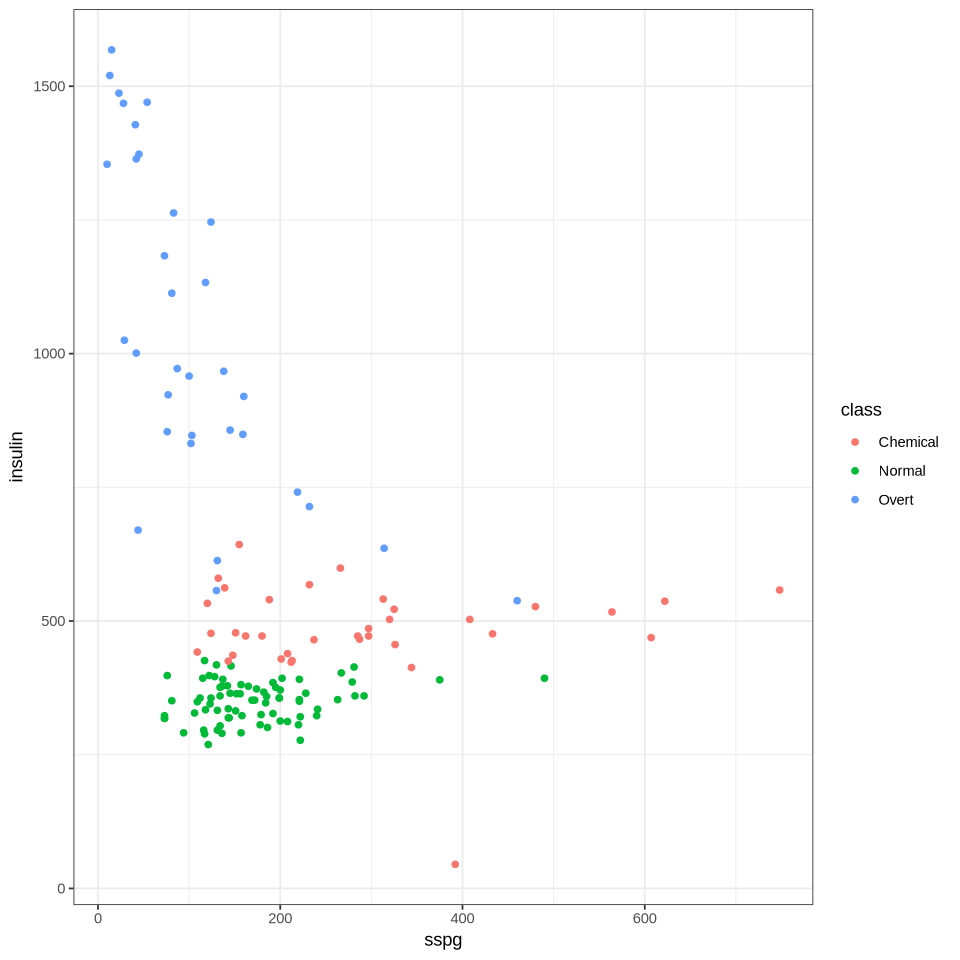

In [9]:
ggplot(diabetesTib, aes(sspg, insulin, col=class)) + geom_point() + theme_bw()

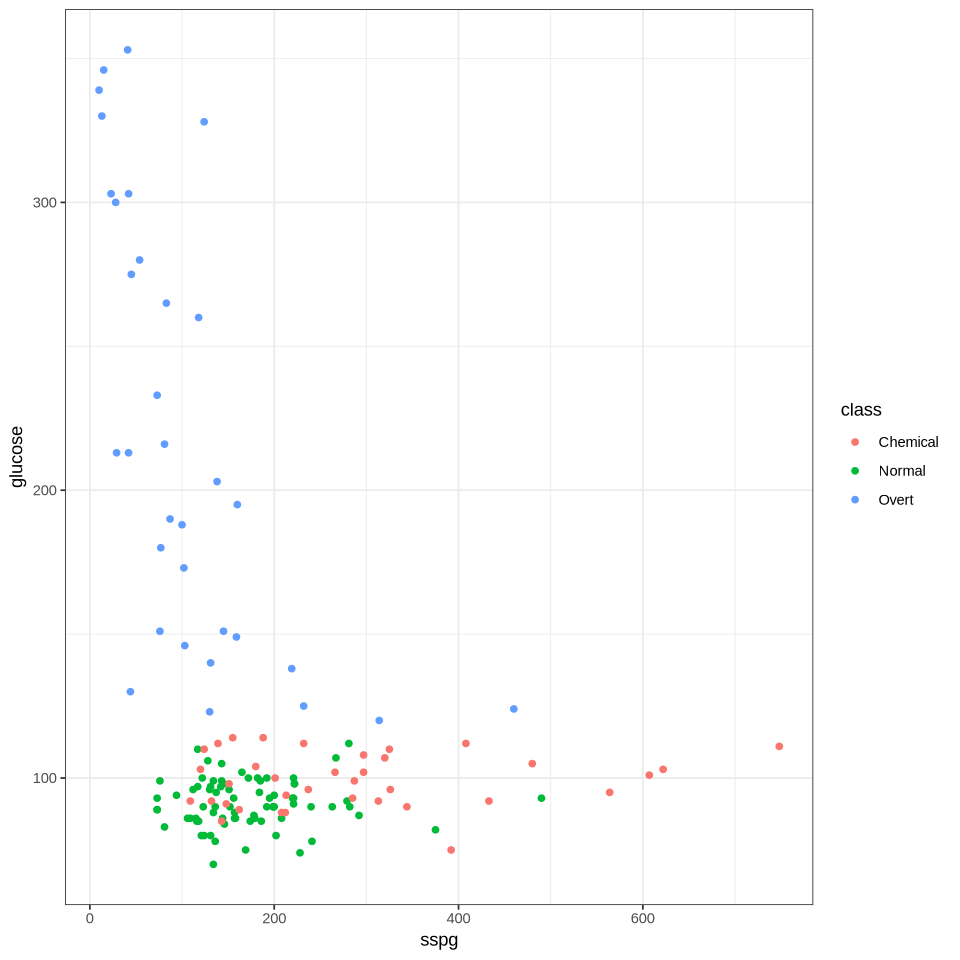

In [10]:
ggplot(diabetesTib, aes(sspg, glucose, col=class)) + geom_point() + theme_bw()

In [11]:
#k nearest neighbors supervised learning algorithm!
#the training phase

#calculate distance
#rank neighbors
#vote k neighbors
#group votes by class and sort them with major votes
#the major wins!

#lazy learner!

#euclidean distance

#when there are two we chose three and there will win somebody!

In [12]:
#three class classification problem

you pass the task to learner and generates the model

In [17]:
diabetesTask <- makeClassifTask(data = diabetesTib, target = 'class')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [18]:
diabetesTask

Supervised task: diabetesTib
Type: classif
Target: class
Observations: 145
Features:
   numerics     factors     ordered functionals 
          3           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: FALSE
Has coordinates: FALSE
Classes: 3
Chemical   Normal    Overt 
      36       76       33 
Positive class: NA

In [31]:
knn <- makeLearner('classif.knn', par.vals = list('k'=2))

In [32]:
knn

Learner classif.knn from package class
Type: classif
Name: k-Nearest Neighbor; Short name: knn
Class: classif.knn
Properties: twoclass,multiclass,numerics
Predict-Type: response
Hyperparameters: k=2


In [30]:
listLearners('cluster')$class

Warning message in listLearners.character("cluster"):
“The following learners could not be constructed, probably because their packages are not installed:
classif.ada,classif.adaboostm1,classif.boosting,classif.bst,classif.C50,classif.cforest,classif.clusterSVM,classif.ctree,classif.dbnDNN,classif.dcSVM,classif.earth,classif.evtree,classif.fdausc.glm,classif.fdausc.kernel,classif.fdausc.knn,classif.fdausc.np,classif.FDboost,classif.fgam,classif.fnn,classif.gamboost,classif.gaterSVM,classif.gausspr,classif.gbm,classif.glmboost,classif.h2o.deeplearning,classif.h2o.gbm,classif.h2o.glm,classif.h2o.randomForest,classif.IBk,classif.J48,classif.JRip,classif.kknn,classif.ksvm,classif.LiblineaRL1L2SVC,classif.LiblineaRL1LogReg,classif.LiblineaRL2L1SVC,classif.LiblineaRL2LogReg,classif.LiblineaRL2SVC,classif.LiblineaRMultiClassSVC,classif.lssvm,classif.mda,classif.mlp,classif.neuralnet,classif.nnTrain,classif.OneR,classif.pamr,classif.PART,classif.penalized,classif.plr,classif.plsdaCaret,classif

[1] "cluster.cmeans"          "cluster.Cobweb"         
 [3] "cluster.dbscan"          "cluster.EM"             
 [5] "cluster.FarthestFirst"   "cluster.kkmeans"        
 [7] "cluster.kmeans"          "cluster.MiniBatchKmeans"
 [9] "cluster.SimpleKMeans"    "cluster.XMeans"

In [36]:
knnModel = train(knn, diabetesTask)

In [37]:
preknnModel

Model for learner.id=classif.knn; learner.class=classif.knn
Trained on: task.id = diabetesTib; obs = 145; features = 3
Hyperparameters: k=2

In [41]:
knnPred = predict(knnModel, newdata = diabetesTib)

Warning message in predict.WrappedModel(knnModel, newdata = diabetesTib):
“Provided data for prediction is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [42]:
knnPred

Prediction: 145 observations
predict.type: response
threshold: 
time: 0.00
   truth response
1 Normal   Normal
2 Normal   Normal
3 Normal   Normal
4 Normal   Normal
5 Normal   Normal
6 Normal   Normal
... (#rows: 145, #cols: 2)

In [69]:
without = performance(knnPred, measures = list(mmce, acc))
without

mmce        acc 
0.03448276 0.96551724

#leave one out cross validation

#underfitted is biased poor on training!

#overfitted the data poor on validation!

k nearest neighbors is not linear pero puede overfit y underfit

cross validation!

#hold out cv

#los dos se evaluan

#making a holdout resampling description

#mantains the proportion of each class on each set

en el task no se hace el holdout

In [58]:
diabetesTask <- makeClassifTask(data = diabetesTib, target = 'class')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [59]:
knn <- makeLearner('classif.knn', par.vals = list('k'=2))

In [56]:
holdout <- makeResampleDesc(method = 'Holdout', split = 2/3, stratify = TRUE)

In [57]:
holdout

Resample description: holdout with 0.67 split rate.
Predict: test
Stratification: TRUE

esto hace la validacion total

In [90]:
holdoutCV <- resample(
    learner = knn, 
    task = diabetesTask, 
    resampling = holdout, 
    measures = list(mmce, acc)
)

Resampling: holdout

Measures:             mmce      acc       

[Resample] iter 1:    0.1224490 0.8775510 




Aggregated Result: mmce.test.mean=0.1224490,acc.test.mean=0.8775510






In [71]:
without

mmce        acc 
0.03448276 0.96551724

In [91]:
holdoutCV$aggr

mmce.test.mean  acc.test.mean 
      0.122449       0.877551

In [85]:
holdoutCV

Resample Result
Task: diabetesTib
Learner: classif.knn
Aggr perf: mmce.test.mean=0.0408163,acc.test.mean=0.9591837
Runtime: 0.0126178

In [92]:
#test set evaluation
calculateConfusionMatrix(holdoutCV$pred, relative = TRUE)

Relative confusion matrix (normalized by row/column):
          predicted
true       Chemical  Normal    Overt     -err.-   
  Chemical 0.92/0.69 0.00/0.00 0.08/0.10 0.08     
  Normal   0.12/0.19 0.88/1.00 0.00/0.00 0.12     
  Overt    0.18/0.12 0.00/0.00 0.82/0.90 0.18     
  -err.-        0.31      0.00      0.10 0.12     


Absolute confusion matrix:
          predicted
true       Chemical Normal Overt -err.-
  Chemical       11      0     1      1
  Normal          3     23     0      3
  Overt           2      0     9      2
  -err.-          5      0     1      6

k fold cross validation

hold out

all the folds have been used once as the test set.

In [93]:
#se hace 10 fold 5 veces
#y se shufflea
#repeated k fold!
#classes have to be stratiffied among the folds

In [116]:
kFold <- makeResampleDesc(
    method = 'RepCV',
    folds = 10,
    reps = 50,
    stratify = TRUE
)

kFold

Resample description: repeated cross-validation with 500 iterations: 10 folds and 50 reps.
Predict: test
Stratification: TRUE

In [117]:
kFoldCV <- resample(
    learner = knn, 
    task = diabetesTask, 
    resampling = kFold, 
    measures = list(mmce, acc)
)

Resampling: repeated cross-validation

Measures:             mmce      acc       

[Resample] iter 1:    0.0714286 0.9285714 

[Resample] iter 2:    0.1250000 0.8750000 

[Resample] iter 3:    0.0000000 1.0000000 

[Resample] iter 4:    0.1538462 0.8461538 

[Resample] iter 5:    0.0000000 1.0000000 

[Resample] iter 6:    0.0000000 1.0000000 

[Resample] iter 7:    0.2000000 0.8000000 

[Resample] iter 8:    0.0666667 0.9333333 

[Resample] iter 9:    0.1428571 0.8571429 

[Resample] iter 10:   0.1333333 0.8666667 

[Resample] iter 11:   0.1250000 0.8750000 

[Resample] iter 12:   0.0714286 0.9285714 

[Resample] iter 13:   0.0666667 0.9333333 

[Resample] iter 14:   0.1538462 0.8461538 

[Resample] iter 15:   0.2142857 0.7857143 

[Resample] iter 16:   0.0666667 0.9333333 

[Resample] iter 17:   0.1333333 0.8666667 

[Resample] iter 18:   0.0666667 0.9333333 

[Resample] iter 19:   0.0714286 0.9285714 

[Resample] iter 20:   0.0714286 0.9285714 

[Resample] iter 21:   0.1428571 0.857

In [118]:
kFoldCV$aggr

mmce.test.mean  acc.test.mean 
     0.1027239      0.8972761